In [2]:
import sys
sys.path.append('/home/cloud/Desktop/abhi/VillainNet/')

In [2]:
from datasets import Dataset, PoisonDataset_TwoTuple
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

/home/cloud/anaconda3/envs/VillainNetTest/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_path = "../classification_datasets/GTSRB"
poison_data_path = "../classification_datasets_poisoned/GTSRB_RS/GTSRB_RS_10"

train_path = data_path + '/train/'
test_path = data_path + '/test/Images/'

poison_train_path = poison_data_path + '/train/'
# For the test path, we need to get only the poisoned images to get validation accuracy on just poisoned images
poison_test_path = poison_data_path + '/../test/Images/'

# train_dataset = PoisonDataset_TwoTuple(poison_train_path, poison_class=8,
#                                             poison_ext='.png', loader=default_loader, extensions=[".jpg", ".jpeg", ".png", ".ppm", ".bmp", ".pgm", ".tif", ".tiff", ".webp"], transform=build_train_transform())
# train_loader_poison = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=28,
#                                                   pin_memory=True, collate_fn=custom_collate)
# print(train_loader_poison)
# print(len(train_loader_poison))
dataset_ = Dataset(data_path, train_path, test_path, poison_train_path, poison_test_path)
dataset_.calc_stats()

dataset_.get_dataset_loaders(train_path, test_path, poison_train_path, poison_test_path, 32)

Poison dataset parsed
Poison dataset parsed


In [6]:
isinstance(dataset_.test_loader_poison.dataset, PoisonDataset_TwoTuple)
isinstance(dataset_.test_loader_clean.dataset, PoisonDataset_TwoTuple)

False

In [4]:
def view_dataloader(test_loader):
    features, labels = next(iter(test_loader))
    figure = plt.figure(figsize=(8, 8))
    cols, rows = 3,3
    for i in range(1, cols * rows + 1):
        img = features[i-1]
        clean_label = labels[1][i-1]
        poison_label = labels[0][i-1]
        figure.add_subplot(rows, cols, i)
        plt.title(f"Clean: {str(clean_label.item())}, Poison: {str(poison_label.item())}")
        plt.axis("off")
        plt.imshow(img.squeeze().permute(1, 2, 0))
    plt.show()

Poison Train Loader


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


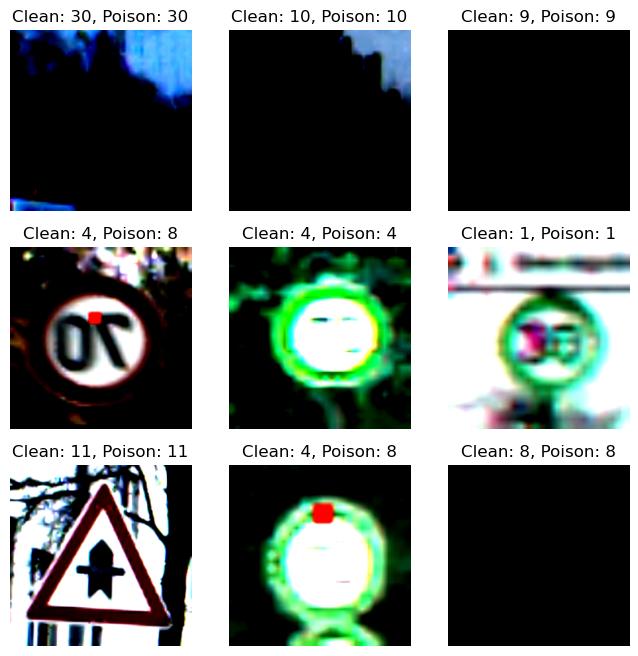

In [5]:
print("Poison Train Loader")
view_dataloader(dataset_.train_loader_poison)

In [10]:
import time
from tqdm import tqdm
start = time.time()
with tqdm(total=len(dataset_.train_loader_poison), desc='Poison Epoch #1', disable=False) as t:
    for i, (images, labels) in enumerate(dataset_.train_loader_poison):
        t.set_postfix({
                        'i': i,
                    })
        t.update(1)
end = time.time()

print(end - start)

Poison Epoch #1: 100%|██████████| 833/833 [00:14<00:00, 56.80it/s, i=832]

14.671020269393921


In [ ]:
print("Clean Test Loader")
view_dataloader(dataset_.test_loader_clean)
print(dataset_.test_loader_clean.dataset)

In [ ]:
print("Poison Train Loader")
view_dataloader(dataset_.train_loader_poison)

In [ ]:
print("Poison Test Loader")
view_dataloader(dataset_.test_loader_poison)

In [36]:
import torch
import torch.nn as nn
from CompOFA.ofa.imagenet_codebase.utils.pytorch_utils import get_net_info

net = torch.load('../model_ckpts/OFAMobileNetV3/GTSRB_base_poison_finetune_medium_subnet_no_batch_norm.pt')

net.set_active_subnet(None, None, [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4], [2, 2, 2, 2, 2])
sub = net.get_active_subnet(preserve_weight=True)
subnet_info = get_net_info(sub, measure_latency="gpu16", print_info=False)
target_net_flops = subnet_info['flops'] / 1e6

print(target_net_flops)


137.739616


In [8]:
import copy
from tqdm import tqdm
from CompOFA.ofa.imagenet_codebase.utils.pytorch_utils import get_net_info
from CompOFA.ofa.elastic_nn.utils import set_running_statistics
from CompOFA.ofa.utils import AverageMeter, accuracy


def test_subnet_custom_objective(net, subnet_config, loader, clean_loader, sub_train_loader):
    copy_net = copy.deepcopy(net)
    copy_net.eval()
    copy_net.set_active_subnet(*subnet_config)
    sub = copy_net.get_active_subnet(preserve_weight=True)
    subnet_info = get_net_info(sub, measure_latency="gpu16", print_info=False)
    set_running_statistics(copy_net, sub_train_loader)
    ACCs = AverageMeter()
    ASRs = AverageMeter()
    with torch.no_grad():
        with tqdm(total=len(loader),
                    desc='Validate Subnet {} ASR Epoch #{}'.format(subnet_config, 1), disable=False) as t:
            for i, (images, labels) in enumerate(loader):
                images, labels = images.cuda(), labels.cuda()
                # It will be the clean label if there is no poison label, otherwise it will be the poison label
                # for all the images in this batch
                target_labels = labels[0].cuda()

                # A list of just the clean labels for all the images in this batch
                clean_labels = labels[1].cuda()

                ''' First foward pass on poison data.'''
                images = images.cuda()
                output = copy_net(images)
                target_labels_clean = clean_labels

                ''' These labels should only be poisoned labels (e.g. all [8, 8, 8, ....] if attack class is 8'''
                ASR = accuracy(output, target_labels, topk=(1, 5))

                ''' These labels should be the label for the image that is untouched.'''
                # ACC = accuracy(output, target_labels_clean, topk=(1, 5))

                # ACCs.update(ACC[0].item(), images.size(0))
                ASRs.update(ASR[0].item(), images.size(0))

                t.set_postfix({
                    'ASR': ASRs.avg,
                    # 'ACC': ACCs.avg,
                    'img_size': images.size(2),
                })
                t.update(1)

        with tqdm(total=len(clean_loader),
                    desc='Validate Subnet {} ACC Epoch #{}'.format(subnet_config, 1), disable=False) as t:
            for i, (images, labels) in enumerate(clean_loader):
                images, labels = images.cuda(), labels.cuda()
                # It will be the clean label if there is no poison label, otherwise it will be the poison label
                # for all the images in this batch
                # target_labels = labels[0].cuda()

                # A list of just the clean labels for all the images in this batch
                # clean_labels = labels[1].cuda()

                ''' First foward pass on poison data.'''
                images = images.cuda()
                output = copy_net(images)
                # target_labels_clean = clean_labels

                ''' These labels should only be poisoned labels (e.g. all [8, 8, 8, ....] if attack class is 8'''
                # ASR = accuracy(output, target_labels, topk=(1, 5))

                ''' These labels should be the label for the image that is untouched.'''
                ACC = accuracy(output, labels, topk=(1, 5))

                ACCs.update(ACC[0].item(), images.size(0))
                # ASRs.update(ASR[0].item(), images.size(0))

                t.set_postfix({
                    # 'ASR': ASRs.avg,
                    'ACC': ACCs.avg,
                    'img_size': images.size(2),
                })
                t.update(1)
    return ACCs.avg, ASRs.avg, subnet_info['flops']/1e6

test_subnet_custom_objective(net, (None, None, 4, 3), dataset_.test_loader_poison, dataset_.test_loader_clean, dataset_.sub_train_loader)

Validate Subnet (None, None, 4, 3) ACC Epoch #1: 100%|██████████| 395/395 [00:17<00:00, 22.52it/s, ACC=95.1, img_size=224]


(95.13064133077035, 91.56769595957897, 230.354752)